In [1]:
import os
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch
mpl.rcParams['figure.dpi'] = 150

In [2]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
# source = "casesm2_10km_nocumulus"
source = "IMERGv7"

# MCS masks
root_dir = f"/pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/mcstracking/"
# in_zarr = f"{root_dir}IMERGv7_hrly_mcsmask_hp8_v1_{year}0101.0000_{int(year)+1}0101.0100.zarr"
in_zarr = f"{root_dir}IMERGv7_hrly_mcsmask_hp8_v1.zarr"

print(f"{in_zarr}: os.path.exists={os.path.exists(in_zarr)}")

# # Combined all feature masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
# in_zarr

/pscratch/sd/w/wcmca1/hackathon/mcs/IMERGv7/mcstracking/IMERGv7_hrly_mcsmask_hp8_v1.zarr: os.path.exists=True


In [3]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 331GB
Dimensions:   (time: 26296, cell: 786432, crs: 0)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
  * crs       (crs) float64 0B 
  * time      (time) datetime64[ns] 210kB 2019-01-01 ... 2021-12-31T23:00:00
Data variables:
    ccs_mask  (time, cell) float64 165GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
    mcs_mask  (time, cell) float64 165GB dask.array<chunksize=(24, 262144), meta=np.ndarray>
Attributes: (12/15)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Mon Mar 16 19:51:52 2026
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    pf_smooth_window:          5
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [4]:
mcs_mask20 = ds.sel(time="2020-01-01T00:00:00").mcs_mask
mcs_mask20

<xarray.DataArray 'mcs_mask' (cell: 786432)> Size: 6MB
dask.array<getitem, shape=(786432,), dtype=float64, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    time     datetime64[ns] 8B 2020-01-01
Attributes:
    comments:   This mask renumbers small merge/split tracks to the main trac...
    long_name:  Track number including merge/split
    units:      unitless

In [5]:
mcs_mask21 = ds.sel(time="2021-01-01T00:00:00").mcs_mask
mcs_mask21

<xarray.DataArray 'mcs_mask' (cell: 786432)> Size: 6MB
dask.array<getitem, shape=(786432,), dtype=float64, chunksize=(262144,), chunktype=numpy.ndarray>
Coordinates:
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    time     datetime64[ns] 8B 2021-01-01
Attributes:
    comments:   This mask renumbers small merge/split tracks to the main trac...
    long_name:  Track number including merge/split
    units:      unitless

In [6]:
ds.chunks

Frozen({'time': (24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,

In [7]:
ds.mcs_mask.attrs

{'comments': 'This mask renumbers small merge/split tracks to the main track (e.g., MCS)',
 'long_name': 'Track number including merge/split',
 'units': 'unitless'}

Text(0.5, 1.0, '2020-01-01T00')

<Figure size 960x720 with 0 Axes>

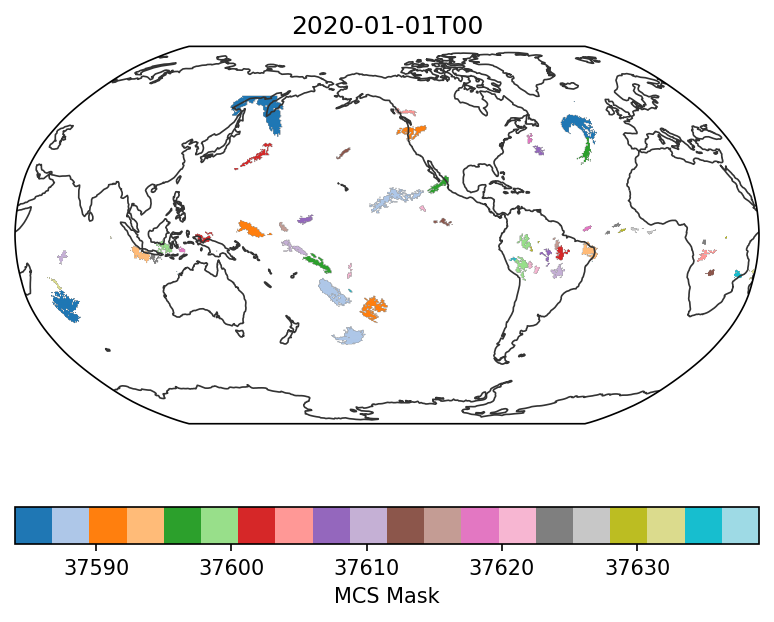

In [8]:
itime = "2020-01-01T00"
mcs_mask20 = ds.sel(time=itime).mcs_mask
im = egh.healpix_show(mcs_mask20.where(mcs_mask20 > 0), cmap='tab20')
plt.colorbar(im, label='MCS Mask', orientation='horizontal')
plt.title(f"{itime}")

Text(0.5, 1.0, '2021-01-01T00')

<Figure size 960x720 with 0 Axes>

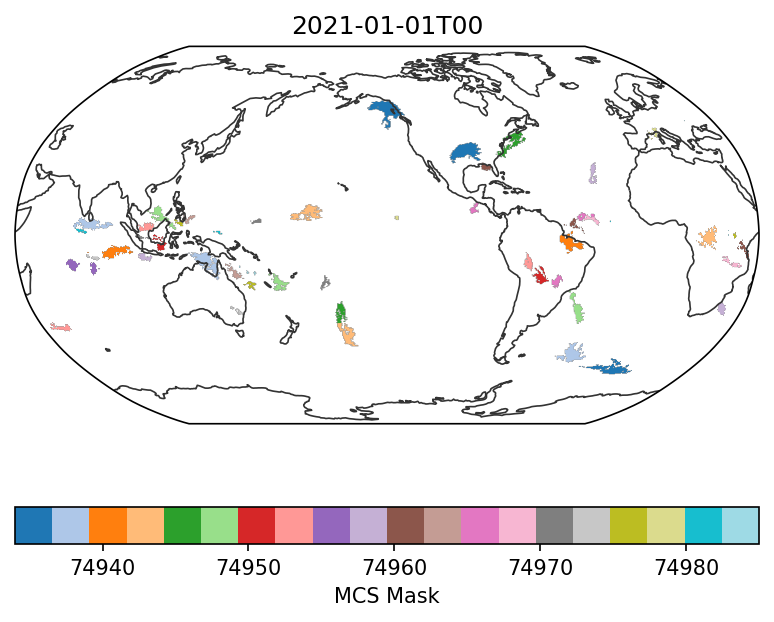

In [9]:
itime = "2021-01-01T00"
mcs_mask21 = ds.sel(time=itime).mcs_mask
im = egh.healpix_show(mcs_mask21.where(mcs_mask21 > 0), cmap='tab20')
plt.colorbar(im, label='MCS Mask', orientation='horizontal')
plt.title(f"{itime}")

In [10]:
sdate = f'2020-08-01T00'
edate = f'2020-08-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 960x720 with 0 Axes>

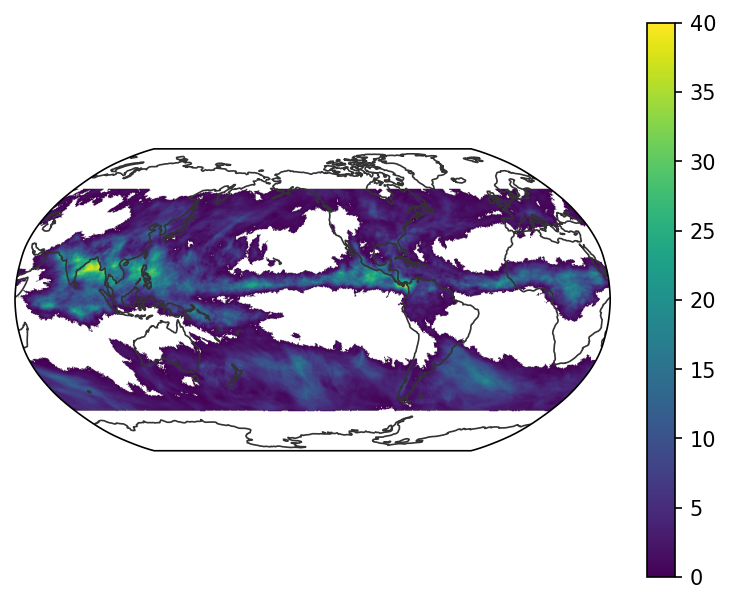

In [11]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [12]:
mcs_freq.max().values

array(39.78494624)